# Loading modules

In [14]:
# WILD OAT https://github.com/asydesign/Wheat-Weed-Dataset
from torch.utils.data import Dataset, WeightedRandomSampler
from utils.loss_utils import LabelSmoothingCrossEntropy
from torch.utils.flop_counter import FlopCounterMode
from sklearn.metrics import f1_score, r2_score
from timeit import default_timer as timer 
from torch.utils.data import DataLoader
from typing import Tuple, Dict, List
from torchvision import transforms
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch.nn as nn
import seaborn as sns
import pandas as pd
import numpy as np
import ResNetC
import random
import EffNet
import torch
import PVTv2
import glob
import ViT


# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.is_available()

True

# Loading Images from path

In [15]:
# Join images and labels together
dataset = []
val_dataset = []
names = ["cirsium arvense", "avena fatua", "setaria viridis"]
path = ["Dataset", "Dataset/validation"]
for p in path:
    for name in names:
        print(fr"./{p}/{name}/*.jpg")
        for filename in glob.glob(fr'./{p}/{name}/*.jpg'): 
            im = Image.open(filename)
            if p == "Dataset":
                dataset.append([im, name])
            else:
                val_dataset.append([im, name])

#for filename in glob.glob(r'./Dataset/avena fatua/*.jpg'): 
#    im = Image.open(filename)
#    dataset.append([im, "avena fatua"])

#for filename in glob.glob(r'./Dataset/setaria viridis/*.jpg'): 
#    im = Image.open(filename)
#    dataset.append([im, "setaria viridis"])

print(len(dataset))
print(len(val_dataset))

./Dataset/cirsium arvense/*.jpg
./Dataset/avena fatua/*.jpg
./Dataset/setaria viridis/*.jpg
./Dataset/validation/cirsium arvense/*.jpg
./Dataset/validation/avena fatua/*.jpg
./Dataset/validation/setaria viridis/*.jpg
2243
263


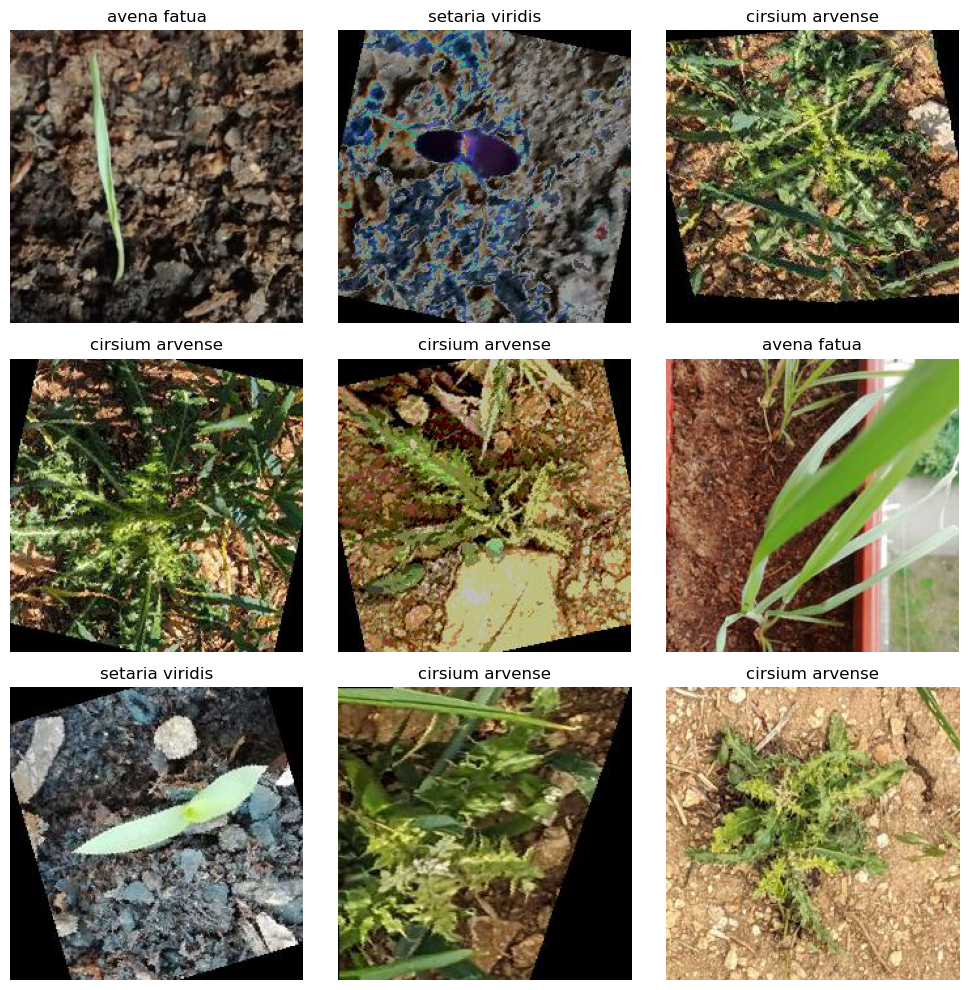

In [16]:
# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i in range(0, 9):
    ran = random.randint(0, len(dataset))
    axes[i].imshow(dataset[ran][0])
    axes[i].axis('off')
    axes[i].set_title(dataset[ran][1])
    
plt.tight_layout()
plt.show()

# Defining custom dataset

In [17]:
# Custom Dataset initialization 
class WeedsDataset(Dataset):
    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, dataset: str, transform=None) -> None:
        self.images = dataset
        self.transform = transform
        self.class_idx = {"cirsium arvense" : 0, "avena fatua" : 1, "setaria viridis" : 2}

    def load_image(self, index: int) -> Image.Image:
        #rint(self.images[index])
        return self.images[index][0]
    
    def __len__(self) -> int:
        return len(self.images)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name  = self.images[index][1]
        class_idx = self.class_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

# Defining Testing, Training Steps, EarlyStopping, and FLOP counter

In [43]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0,
                 mode: str = "min", checkpoint_path: str = "best_model.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.checkpoint_path = checkpoint_path

        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def _is_improvement(self, score):
        if self.best_score is None:
            return True
        if self.mode == "min":
            return score < self.best_score - self.min_delta
        return score > self.best_score + self.min_delta

    def step(self, score, model):
        if self._is_improvement(score):
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), self.checkpoint_path)  # save best weights
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          patience: int = 5,
          monitor: str = "test_loss",
          checkpoint_path: str = "best_model.pt",
          scheduler: torch.optim.lr_scheduler._LRScheduler = None,
          scaler: torch.cuda.amp.GradScaler = None,
          device: torch.device = None):

    # Defining early stopping
    early_stopping = EarlyStopping(
        patience=patience,
        mode="min" if "loss" in monitor else "max",
        checkpoint_path=checkpoint_path
    )
    
    # 2. Create empty results dictionary
    results = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": [],
               "f1_score": [], "correct": [], "incorrect": [],
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    use_amp = scaler is not None and device.type == "cuda"
    for epoch in tqdm(range(epochs)):
        model.train()
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            scaler=scaler,
            device=device
        )

        model.eval()
        test_loss, test_acc, f1_score, correct, incorrect = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        # Handling learning rate scheduling
        if scheduler is not None:
            # ReduceLROnPlateau needs the metric; others don't
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        # Helper function
        def to_py(v):
            return v.item() if isinstance(v, torch.Tensor) else v

        # 5. Update results dictionary
        results["train_loss"].append(to_py(train_loss))
        results["train_acc"].append(to_py(train_acc))
        results["test_loss"].append(to_py(test_loss))
        results["test_acc"].append(to_py(test_acc))
        results["f1_score"].append(to_py(f1_score))
        results["correct"].append(to_py(correct))
        results["incorrect"].append(to_py(incorrect))

        
        # 4. Print out what's happening
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | F1-Score: {f1_score:.4f} | "
            f"lr: {current_lr:.2e} | ES patience: {early_stopping.counter}/{patience}"
        )

        
        # Handling early stopping
        early_stopping.step(results[monitor][-1], model)
        if early_stopping.should_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}. "
                  f"Best {monitor}: {early_stopping.best_score:.4f}")
            break

    # 6. Return the filled results at the end of the epochs
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Best weights restored from '{checkpoint_path}'")

    return results

def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               scaler: torch.cuda.amp.GradScaler = None,
               device: torch.device = None):


    # Put model in train mode
    model.train()
    train_loss, train_acc = 0, 0
   
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)


        with torch.autocast(device_type="cuda"):
                y_pred = model(X)
                loss = loss_fn(y_pred, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # 3. Optimizer zero grad
        optimizer.zero_grad(set_to_none=True)
        train_loss += loss.item() 

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device = None):
    # Put model in eval mode
    model.eval() 

    y_true = []
    y_p = []
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    correct, incorrect = 0, 0
    use_amp = device is not None and device.type == "cuda"
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            # 1. Forward pass
            with torch.autocast(device_type="cuda", enabled=use_amp):
                test_pred_logits = model(X)
                loss = loss_fn(test_pred_logits, y)
            
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            correct += (test_pred_labels == y).sum().item()
            incorrect += len(y) - (test_pred_labels == y).sum()

            
            # Calculate and accumulate accuracy metrics across all batches
            y_p.extend(test_pred_labels.cpu().numpy())
            y_true.extend(y.cpu().numpy())

    f1 = f1_score(y_true, y_p, average="macro")
            
    # Adjust metrics to get average loss and accuracy per batch 
    return test_loss / len(dataloader), test_acc / len(dataloader), f1, correct, incorrect

from tqdm.auto import tqdm
import torch.nn as nn

# 1. Take in various parameters required for training and test steps
def validation(model: torch.nn.Module, 
              val_dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
              epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {
        "val_loss": [],
        "val_acc": [],
        "f1_score": [],
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    #for epoch in tqdm(range(epochs)):
    val_loss, val_acc, f1_score, _, _ = test_step(model=model,
        dataloader=val_dataloader,
        loss_fn=loss_fn)
        
    # 4. Print out what's happening
    print(
        f"Epoch: 1 | "
        f"test_loss: {val_loss:.4f} | "
        f"test_acc: {val_acc:.4f} | "
        f"F1-Score: {f1_score:.4f} | "
    )

    # 5. Update results dictionary
    # Ensure all data is moved to CPU and converted to float for storage
    results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
    results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)
    results["f1_score"].append(f1_score.item() if isinstance(f1_score, torch.Tensor) else f1_score)

        #del val_loss, val_acc, f1_score


    # 6. Return the filled results at the end of the epochs
    return results

def get_flops(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader):
    model.eval()
    img = torch.randn(1, 3, 224, 224).to(device)  # single sample, representative shape
    with FlopCounterMode(model, display=False) as flop_counter:
        with torch.no_grad():
            model(img)

    flops_per_image = flop_counter.get_total_flops()
    dataset_size = len(dataloader.dataset)
    total_flops = flops_per_image * dataset_size
        
    print(f"FLOPs per image : {flops_per_image / 1e9:.2f} GFLOPs")
    print(f"Dataset size    : {dataset_size}")
    print(f"Total FLOPs     : {total_flops / 1e12:.4f} TFLOPs")
    return (flops_per_image / 1e9, total_flops / 1e12)

# Instanciating dataset with shuffles, augmentation, and normalisation

In [21]:
# Centering each image around 0 in a [-1, 1] range.
# https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8 (Find more reliable source and cite)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)
train_transforms = transforms.Compose([
    #transforms.TrivialAugmentWide(num_magnitude_bins=25), # how intense 
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std), # Is there any other way to normalize without calling compose twice?
    #transforms.RandomErasing(p=1), # Testing random erasure (not working for some reason)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


train_25 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.25), # Testing random erasure (not working for some reason)
])


train_50 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.5), # Testing random erasure (not working for some reason)
])

# Creating Test and Training sets 
length = len(dataset)
train_data_len = int(length*0.80)
train_data, test_data = train_set, val_set = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len])
train_data_0 = WeedsDataset(dataset=train_data, transform=train_transforms)
train_data_25 = WeedsDataset(dataset=train_data, transform=train_25)
train_data_50= WeedsDataset(dataset=train_data, transform=train_50)
test_data = WeedsDataset(dataset=test_data, transform=test_transforms)

validation_data = WeedsDataset(dataset=val_dataset, transform=test_transforms)
val_dataloader = DataLoader(dataset=validation_data, # use custom created test Dataset
                                    batch_size=32, 
                                    num_workers=0, 
                                    shuffle=False) 


train_dataloader = DataLoader(dataset=train_data_0, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_25 = DataLoader(dataset=train_data_25, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_50 = DataLoader(dataset=train_data_50, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data, # use custom created test Dataset
                                    batch_size=32, 
                                    num_workers=0, 
                                    shuffle=False) # don't usually need to shuffle testing data


In [48]:
# Set random seeds and max epochs
torch.manual_seed(42) 
torch.cuda.manual_seed(42)
NUM_EPOCHS = 50
datasets = [train_dataloader, train_dataloader_25, train_dataloader_50]
dataset_names = ["Original Dataset", "Occluded - 25", "Occluded - 50"]
torch.autograd.set_detect_anomaly(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss = LabelSmoothingCrossEntropy().to(device)

# ViT

In [ ]:
sample_img = torch.randn(1, 3, 224, 224).to(device)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


all_results = {}
for name, dataset in zip(dataset_names, datasets):
    print(f"\n{'='*50}")
    print(f"Training on: {name}")
    print(f"{'='*50}")
    model = ViT.ViTClassifier(sample_img, num_classes=3).to(device) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
        
    checkpoint_path = f"vit_best_model_{name}.pt"
    
    results = train(
        model=model,
        train_dataloader=dataset,
        test_dataloader=test_dataloader,
        loss_fn=loss,
        optimizer=optimizer,
        epochs=50,
        patience=7,
        monitor="test_loss",          
        checkpoint_path=checkpoint_path,
        scheduler=scheduler,
        scaler=scaler,
        device=device
    )
    
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
        
    val_loss, val_acc, val_f1, correct, incorrect = test_step(
        model=model,
        dataloader=val_dataloader,
        loss_fn=loss,
        device=device
    )
    
    print(f"\n── {name} Validation Results ──")
    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Validation F1 Score : {val_f1:.4f}")
    print(f"Correct Predictions : {correct}")
    print(f"Incorrect Predictions: {incorrect}")

    model_flops = get_flops(model, dataset)
    print(f"Model FLOPs: {model_flops}")

    all_results[name] = {
        "train_results": results,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "correct": correct,
        "incorrect": incorrect,
        "flops": model_flops,
    }

print(all_results)  

C:\Users\EuanH\AppData\Local\Temp\ipykernel_10420\1410283924.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None



Training on: Original Dataset
196


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1564 | train_acc: 0.4474 | test_loss: 0.9188 | test_acc: 0.6250 | F1-Score: 0.5543 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 2 | train_loss: 0.8979 | train_acc: 0.5729 | test_loss: 0.8881 | test_acc: 0.6000 | F1-Score: 0.4872 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 3 | train_loss: 0.8691 | train_acc: 0.5921 | test_loss: 0.8530 | test_acc: 0.6312 | F1-Score: 0.5051 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 4 | train_loss: 0.8455 | train_acc: 0.5899 | test_loss: 0.7452 | test_acc: 0.6271 | F1-Score: 0.5074 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 5 | train_loss: 0.7950 | train_acc: 0.6458 | test_loss: 0.6371 | test_acc: 0.8208 | F1-Score: 0.8073 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 6 | train_loss: 0.7985 | train_acc: 0.7078 | test_loss: 0.9402 | test_acc: 0.5396 | F1-Score: 0.4150 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 7 | train_loss: 0.9606 | train_acc: 0.5746 | test_loss: 1.0888 | test_acc: 0.4625 | F1-Score: 0.3391 | lr: 1.00e-04 | ES patience: 1/7
Epoch:

C:\Users\EuanH\AppData\Local\Temp\ipykernel_10420\1179329410.py:252: UserWarning: mods argument is not needed anymore, you can stop passing it
  with FlopCounterMode(model, display=False) as flop_counter:


...

Epoch: 1 | train_loss: 1.2892 | train_acc: 0.3344 | test_loss: 1.1486 | test_acc: 0.2875 | F1-Score: 0.1567 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 2 | train_loss: 1.1623 | train_acc: 0.3514 | test_loss: 1.1947 | test_acc: 0.3271 | F1-Score: 0.1727 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 3 | train_loss: 1.1257 | train_acc: 0.3284 | test_loss: 1.0950 | test_acc: 0.3875 | F1-Score: 0.1750 | lr: 1.00e-04 | ES patience: 1/7
Epoch: 4 | train_loss: 1.1159 | train_acc: 0.3487 | test_loss: 1.1206 | test_acc: 0.2875 | F1-Score: 0.1567 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 5 | train_loss: 1.1181 | train_acc: 0.3229 | test_loss: 1.0930 | test_acc: 0.3854 | F1-Score: 0.1703 | lr: 1.00e-04 | ES patience: 1/7
Epoch: 6 | train_loss: 1.1308 | train_acc: 0.3454 | test_loss: 1.0969 | test_acc: 0.3854 | F1-Score: 0.1703 | lr: 1.00e-04 | ES patience: 0/7
Epoch: 7 | train_loss: 1.1133 | train_acc: 0.3366 | test_loss: 1.1292 | test_acc: 0.2875 | F1-Score: 0.1567 | lr: 1.00e-04 | ES patience: 1/7
Epoch:

C:\Users\EuanH\AppData\Local\Temp\ipykernel_10420\1179329410.py:252: UserWarning: mods argument is not needed anymore, you can stop passing it
  with FlopCounterMode(model, display=False) as flop_counter:


FLOPs per image : 35.13 GFLOPs
Dataset size    : 1794
Total FLOPs     : 63.0163 TFLOPs
Model FLOPs: (35.126125056, 63.016268350464)

Training on: Occluded - 50
196


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.2752 | train_acc: 0.3827 | test_loss: 1.1478 | test_acc: 0.2875 | F1-Score: 0.1608 | lr: 1.00e-04 | ES patience: 0/7


In [9]:
# Training


#EffNet = EfficientNet.EfficientNet("B1", in_channels=3, classes=3, show=False).to(device) # EfficientNet-B0 FIGURE OUT WHY TEST ACC ISN'T SHOWING
#RsNet = ResNet.ResNet50(channels=3, num_classes=3).to(device) # ResNet - FIGURE OUT WHY TEST ACC IS AT 100% ALL THE TIME



#PvTv2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 

# Setup loss function and optimizer
#loss_fn = nn.CrossEntropyLoss()



# Creating Test and Training sets 
length = len(dataset)
train_data_len = int(length*0.80)
train_data, test_data = train_set, val_set = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len])

# Start the timer
#start_time = timer()

# Train model_0 
#img_batch, label_batch = next(iter(train_dataloader))
#import EfficientNet

#img_batch, label_batch = next(iter(train_dataloader))
#eff = resnet.ResNet50(num_classes=3).to(device)
#EffNet.EfficientNet.from_pretrained("efficientnet-b0", in_channels=3, num_classes=3, image_size=[224, 224]).to(device) #PVTv2.pvt_v2_b0(pretrained=False, num_classes=3).to(device)
#optimizer_1 = torch.optim.AdamW(params=eff.parameters(), lr=0.00001) #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
#eff_0 = train(model=eff, 
#                        train_dataloader=train_dataloader,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_1,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)
#torch.save(eff.state_dict(), "resnet_0_weights")

img_batch, label_batch = next(iter(train_dataloader))
vit_b16 = ViT.ViTClassifier(img_batch, num_classes=3).to(device)   #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
optimizer_1 = torch.optim.AdamW(params=vit_b16.parameters(), lr=0.00001)
v_0 = train(model=vit_b16, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer_1,
                        loss_fn=loss, 
                        epochs=NUM_EPOCHS)

#end_time = timer()
#print(f"Total training time: {end_time-start_time:.3f} seconds")

196


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7958 | train_acc: 0.6963 | test_loss: 0.5740 | test_acc: 0.8604 | F1-Score: 0.8538 | 
Epoch: 2 | train_loss: 0.6190 | train_acc: 0.8141 | test_loss: 0.6196 | test_acc: 0.7833 | F1-Score: 0.7705 | 
Epoch: 3 | train_loss: 0.5494 | train_acc: 0.8509 | test_loss: 0.5228 | test_acc: 0.8708 | F1-Score: 0.8614 | 
Epoch: 4 | train_loss: 0.5121 | train_acc: 0.8761 | test_loss: 0.4180 | test_acc: 0.9333 | F1-Score: 0.9301 | 
Epoch: 5 | train_loss: 0.4840 | train_acc: 0.8914 | test_loss: 0.4398 | test_acc: 0.9167 | F1-Score: 0.9115 | 
Epoch: 6 | train_loss: 0.4435 | train_acc: 0.9183 | test_loss: 0.5557 | test_acc: 0.8750 | F1-Score: 0.8682 | 
Epoch: 7 | train_loss: 0.4307 | train_acc: 0.9194 | test_loss: 0.4716 | test_acc: 0.9104 | F1-Score: 0.9053 | 
Epoch: 8 | train_loss: 0.4103 | train_acc: 0.9419 | test_loss: 0.4727 | test_acc: 0.9104 | F1-Score: 0.9052 | 
Epoch: 9 | train_loss: 0.3952 | train_acc: 0.9446 | test_loss: 0.3963 | test_acc: 0.9500 | F1-Score: 0.9476 | 
E

# Plotting Results

# Validation

In [12]:
torch.save(vit_b16_25_1.state_dict(), "vit_0_weights")
torch.save(vit_b16_25_2.state_dict(), "vit_50_weights")

    train_loss  train_acc  val_loss   val_acc  f1_score  correct  incorrect
0     0.795792   0.696272  0.573981  0.860417  0.853835      382         67
1     0.618962   0.814145  0.619583  0.783333  0.770464      345        104
2     0.549359   0.850877  0.522762  0.870833  0.861445      387         62
3     0.512061   0.876096  0.418018  0.933333  0.930130      417         32
4     0.483995   0.891447  0.439754  0.916667  0.911469      409         40
5     0.443456   0.918311  0.555702  0.875000  0.868211      389         60
6     0.430655   0.919408  0.471581  0.910417  0.905254      406         43
7     0.410258   0.941886  0.472740  0.910417  0.905186      406         43
8     0.395153   0.944627  0.396343  0.950000  0.947613      425         24
9     0.381311   0.955044  0.607203  0.885417  0.879283      394         55
10    0.404010   0.940789  0.460632  0.929167  0.925335      415         34
11    0.372853   0.956689  0.419631  0.945833  0.942886      423         26
12    0.3760

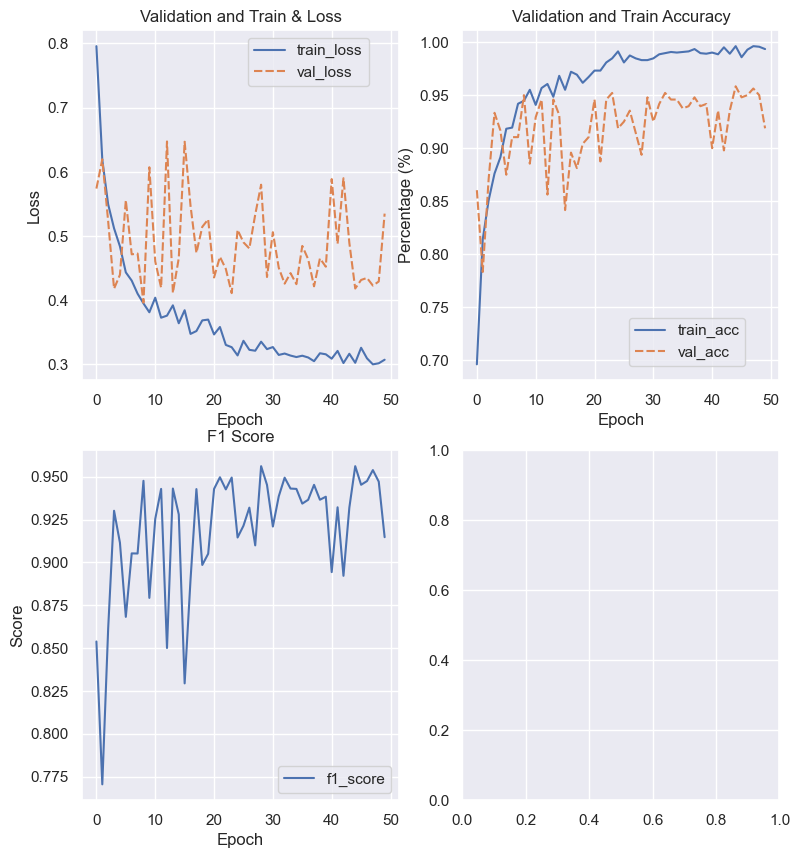

In [14]:
NUM_EPOCHS = 50
x = [i for i in range(1, NUM_EPOCHS+1)]

title = ['Train Accuracy & Loss', 'Test Accuracy & Loss', 'F1 Score']
labels = ['train_loss', 'train_acc', 'test_loss', 'test_acc', 'F1_score']

# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
#model_0_results = eff
df = pd.DataFrame(v_0) #pd.read_csv('Results/training/efficientnet 50 50%.csv') #
df = df.rename(columns={"test_loss": "val_loss", "test_acc": "val_acc"})
print(df)
sns.set_theme()
f, axes = plt.subplots(2, 2, figsize=(9, 10))
axes = axes.flatten()
ax = sns.lineplot(data=df[["train_loss", "val_loss"]], ax=axes[0])
ax.set(title="Validation and Train & Loss", ylabel="Loss", xlabel="Epoch")
lgd = sns.move_legend(ax, "upper left", bbox_to_anchor=(0.5,1))


ax2 = sns.lineplot(data=df[["train_acc", "val_acc"]], ax=axes[1])
ax2.set(title="Validation and Train Accuracy", ylabel="Percentage (%)", xlabel="Epoch")
lgd2 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))

ax3 = sns.lineplot(data=df[["f1_score"]], ax=axes[2])
ax3.set(title="F1 Score", ylabel="Score", xlabel="Epoch")
lgd3 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))
fig = f.get_figure()
#fig.savefig("resnet 32 Batch 50 Epoch 50% LabelSmoothingCrossEntropy.png")

df.to_csv("vit 50 0%.csv", index=True)